In [ ]:
# =========================
# Imports
# =========================
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os 

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import backend as K

In [9]:
# =========================
# Data Preparation
# =========================
training_set = image_dataset_from_directory(
"./train", #Path to the training data directory
labels="inferred",
label_mode="categorical",
class_names=None,
color_mode="rgb",
batch_size=16,
image_size=(224, 224),
shuffle=True,
seed=None,
validation_split=None,
subset=None,
interpolation="bilinear",
follow_links=False,
crop_to_aspect_ratio=False,
)

Found 76515 files belonging to 4 classes.


In [10]:
validation_set = image_dataset_from_directory(
"./val", #Path to the training data directory
labels="inferred",
label_mode="categorical",
class_names=None,
color_mode="rgb",
batch_size=16,
image_size=(224, 224),
shuffle=True,
seed=None,
validation_split=None,
subset=None,
interpolation="bilinear",
follow_links=False,
crop_to_aspect_ratio=False,
)

Found 21861 files belonging to 4 classes.


In [11]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [12]:
INPUT_SHAPE = (224, 224, 3)

In [13]:
mobnet = tf.keras.applications.MobileNetV3Large(
input_shape=INPUT_SHAPE,
alpha=1.0,
minimalistic=False,
include_top=True,
weights="imagenet",
input_tensor=None,
classes=1000,
pooling=None,
dropout_rate=0.2,
classifier_activation="softmax",
include_preprocessing=True,
# name="MobileNetV3Large",
)

In [5]:
# =========================
# Custom F1 Score
# =========================
def f1_score(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.cast(y_true * y_pred, 'float'), axis=0)
    fp = K.sum(K.cast((1 - y_true) * y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true * (1 - y_pred), 'float'), axis=0)

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return K.mean(f1)

metrics_list = ["accuracy", f1_score]

In [14]:
model = tf.keras.Sequential()

In [15]:
model.add(tf.keras.Input(shape=INPUT_SHAPE))

In [16]:
model.add(mobnet)

In [17]:
model.add(tf.keras.layers.Dense(units=4, activation="softmax"))

In [18]:
# created a custom f1 score using function
from tensorflow.keras import backend as K

def f1_score(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.cast(y_true * y_pred, 'float'), axis=0)
    fp = K.sum(K.cast((1 - y_true) * y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true * (1 - y_pred), 'float'), axis=0)

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())

    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return K.mean(f1)

metrics_list = ["accuracy", f1_score]

In [19]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=metrics_list)

In [20]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense_1 (Dense)             (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [22]:
training_history = model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=15
)


Epoch 1/15
4783/4783 [==============================] - 719s 150ms/step - loss: 0.9646 - accuracy: 0.8859 - f1_score: 0.1219 - val_loss: 0.7635 - val_accuracy: 0.8292 - val_f1_score: 0.4546
Epoch 2/15
4783/4783 [==============================] - 710s 148ms/step - loss: 0.5845 - accuracy: 0.9069 - f1_score: 0.4791 - val_loss: 0.4505 - val_accuracy: 0.9593 - val_f1_score: 0.4851
Epoch 3/15
4783/4783 [==============================] - 708s 148ms/step - loss: 0.3802 - accuracy: 0.9548 - f1_score: 0.6385 - val_loss: 0.3064 - val_accuracy: 0.9621 - val_f1_score: 0.6751
Epoch 4/15
4783/4783 [==============================] - 710s 148ms/step - loss: 0.2627 - accuracy: 0.9617 - f1_score: 0.7986 - val_loss: 0.2180 - val_accuracy: 0.9640 - val_f1_score: 0.8372
Epoch 5/15
4783/4783 [==============================] - 710s 148ms/step - loss: 0.1888 - accuracy: 0.9683 - f1_score: 0.8437 - val_loss: 0.1735 - val_accuracy: 0.9685 - val_f1_score: 0.8341
Epoch 6/15
4783/4783 [============================

In [23]:
# =========================
# SAVE MODEL (NEW FILE – SAFE)
# =========================
MODEL_NAME = "Trained_Eye_disease_model_v2.keras"
model.save(MODEL_NAME)
print(f"✅ Model saved as {MODEL_NAME}")

✅ Model saved as Trained_Eye_disease_model_v2.keras


In [24]:
# =========================
# SAVE TRAINING HISTORY (OPTIONAL)
# =========================
HISTORY_NAME = "Training_history_v2.pkl"

with open(HISTORY_NAME, "wb") as f:
    pickle.dump(training_history.history, f)

print("History file size:", os.path.getsize(HISTORY_NAME))

History file size: 920


In [3]:
# Reloading training history
import pickle

with open("Training_history_v2.pkl", "rb") as f:
    load_history = pickle.load(f)

print(load_history)

{'loss': [0.9646016359329224, 0.5844687819480896, 0.38021597266197205, 0.2627033591270447, 0.18878750503063202, 0.14346206188201904, 0.11161898076534271, 0.0899629294872284, 0.07663733512163162, 0.06380438804626465, 0.058313608169555664, 0.052225034683942795, 0.04827494919300079, 0.04560862481594086, 0.041096288710832596], 'accuracy': [0.8859047293663025, 0.9069071412086487, 0.9547670483589172, 0.9616676568984985, 0.9682807326316833, 0.9733908176422119, 0.9783964157104492, 0.9821080565452576, 0.9841991662979126, 0.9872965812683105, 0.9881199598312378, 0.9892700910568237, 0.9900280833244324, 0.9905116558074951, 0.9914134740829468], 'f1_score': [0.12187644839286804, 0.47912365198135376, 0.6385270357131958, 0.7986375093460083, 0.8437198996543884, 0.8528904914855957, 0.8575835824012756, 0.8661746978759766, 0.8653784394264221, 0.8733628392219543, 0.8721508383750916, 0.8801906108856201, 0.8782761693000793, 0.8780226707458496, 0.8782499432563782], 'val_loss': [0.7634727954864502, 0.4504714310

In [26]:
training_history.history

{'loss': [0.9646016359329224,
  0.5844687819480896,
  0.38021597266197205,
  0.2627033591270447,
  0.18878750503063202,
  0.14346206188201904,
  0.11161898076534271,
  0.0899629294872284,
  0.07663733512163162,
  0.06380438804626465,
  0.058313608169555664,
  0.052225034683942795,
  0.04827494919300079,
  0.04560862481594086,
  0.041096288710832596],
 'accuracy': [0.8859047293663025,
  0.9069071412086487,
  0.9547670483589172,
  0.9616676568984985,
  0.9682807326316833,
  0.9733908176422119,
  0.9783964157104492,
  0.9821080565452576,
  0.9841991662979126,
  0.9872965812683105,
  0.9881199598312378,
  0.9892700910568237,
  0.9900280833244324,
  0.9905116558074951,
  0.9914134740829468],
 'f1_score': [0.12187644839286804,
  0.47912365198135376,
  0.6385270357131958,
  0.7986375093460083,
  0.8437198996543884,
  0.8528904914855957,
  0.8575835824012756,
  0.8661746978759766,
  0.8653784394264221,
  0.8733628392219543,
  0.8721508383750916,
  0.8801906108856201,
  0.8782761693000793,
  0.

In [27]:
load_history.keys()

dict_keys(['loss', 'accuracy', 'f1_score', 'val_loss', 'val_accuracy', 'val_f1_score'])

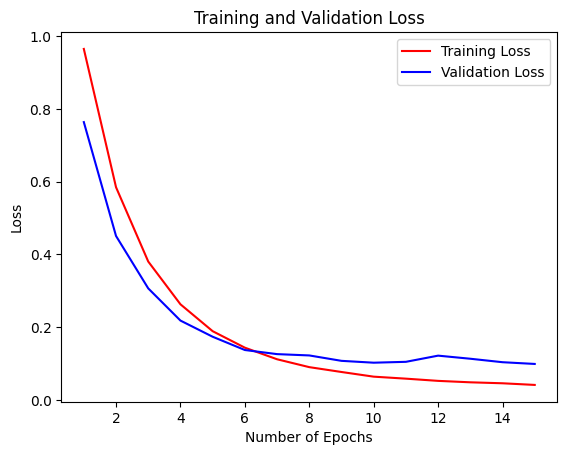

In [28]:
#loss visualization
epochs = [i for i in range(1,16)]
plt.plot(epochs, load_history['loss'], color='red', label='Training Loss')
plt.plot(epochs, load_history['val_loss'], color='blue', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Number of Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Model evalution


In [29]:
# load model with the custom f1_score metric defined earlier
model = tf.keras.models.load_model("./Trained_Eye_disease_model_v2.keras", custom_objects={"f1_score": f1_score})

In [30]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense_1 (Dense)             (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [ ]:
# load model with the custom f1_score metric defined earlier
model = tf.keras.models.load_model("./Trained_Eye_disease_model.h5", custom_objects={"f1_score": f1_score})z

In [31]:
test_set = image_dataset_from_directory(
"./test", #Path to the training data directory
labels="inferred",
label_mode="categorical",
class_names=None,
color_mode="rgb",
batch_size=16,
image_size=(224, 224),
shuffle=False,
seed=None,
validation_split=None,
subset=None,
interpolation="bilinear",
follow_links=False,
crop_to_aspect_ratio=False,
)

Found 10933 files belonging to 4 classes.


In [32]:
test_loss,test_acc,f1_score = model.evaluate(test_set)

684/684 [==============================] - 30s 39ms/step - loss: 0.1125 - accuracy: 0.9728 - f1_score: 0.2472


In [34]:
#computing true labels from test set
true_categories = tf.concat([y for x, y in test_set], axis=0)

Y_true = tf.argmax(true_categories, axis=1)

In [35]:

true_categories

<tf.Tensor: shape=(10933, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], dtype=float32)>

In [36]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [37]:
#computed predicted labels from test set
predicted_categories = model.predict(test_set)
predicted_categories

684/684 [==============================] - 25s 35ms/step


array([[9.9370342e-01, 1.9599807e-03, 3.2851559e-03, 1.0513908e-03],
       [9.9368298e-01, 1.9646082e-03, 3.2977224e-03, 1.0547183e-03],
       [9.9370342e-01, 1.9599451e-03, 3.2853235e-03, 1.0513818e-03],
       ...,
       [5.1993917e-04, 1.5890803e-03, 2.7994970e-03, 9.9509144e-01],
       [5.1993917e-04, 1.5890803e-03, 2.7994970e-03, 9.9509144e-01],
       [5.1993941e-04, 1.5890803e-03, 2.7994970e-03, 9.9509144e-01]],
      dtype=float32)

In [38]:
Y_Pred = tf.argmax(predicted_categories, axis=1)
Y_Pred

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [ ]:
## 1 classification report


In [ ]:
# NOTE:
# This classification report represents the FINAL model evaluation on the
# held-out test dataset. The macro-averaged F1-score (~0.95) and weighted
# F1-score (~0.97) are the official results reported in the dissertation.
# Any lower F1 values observed elsewhere in the code correspond to
# intermediate or experimental evaluations and are not final results.

from sklearn.metrics import classification_report
print(classification_report(Y_true, Y_Pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3746
           1       0.97      0.96      0.96      1161
           2       0.90      0.87      0.88       887
           3       0.98      0.99      0.99      5139

    accuracy                           0.97     10933
   macro avg       0.96      0.95      0.95     10933
weighted avg       0.97      0.97      0.97     10933



In [40]:
## 2 Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_true, Y_Pred)
cm

array([[3667,   13,   57,    9],
       [  14, 1113,    2,   32],
       [  70,    5,  769,   43],
       [   4,   20,   28, 5087]], dtype=int64)

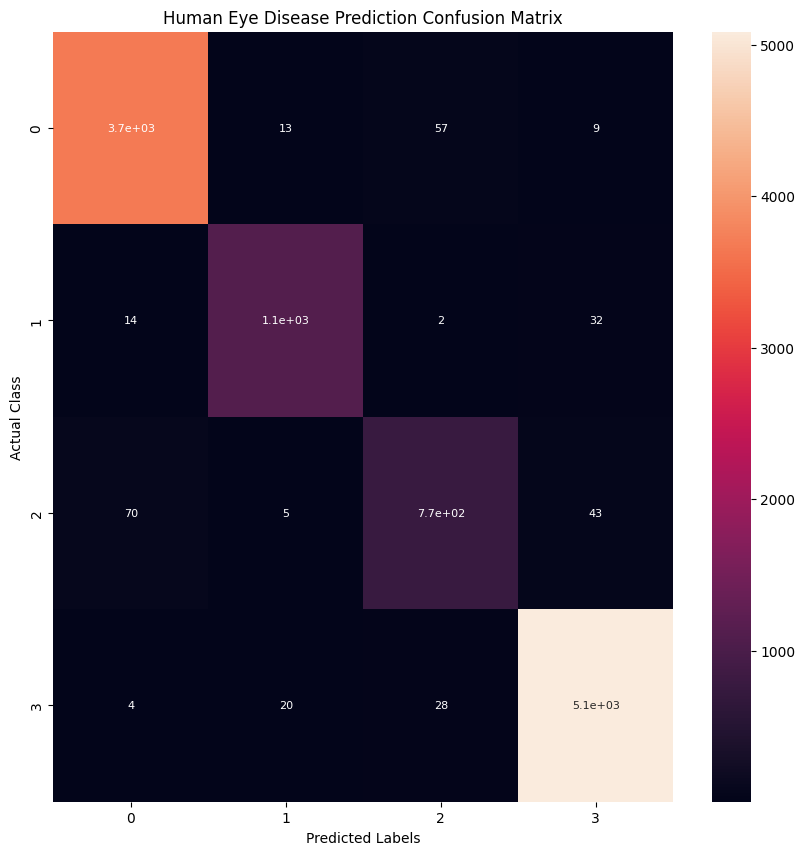

In [41]:
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, annot_kws={"size": 8})
plt.xlabel('Predicted Labels', fontsize=10)
plt.ylabel('Actual Class', fontsize=10)
plt.title('Human Eye Disease Prediction Confusion Matrix',fontsize=12)
plt.show()